**Dataset:** CIC-MalMem-2022

**Objetivo:** Implementar un modelo de regresión logística binaria para clasificar muestras de memoria como benignas o malware, utilizando las características extraídas del dataset CIC-MalMem-2022.

El dataset será preprocesado utilizando Pandas y posteriormente dividido en 80% para entrenamiento y 20% para prueba.




## **1 Dataset**

1. librerías

In [170]:
# Manipulación de datos
import pandas as pd
# Cálculo científico y vectorial
import numpy as np
# Gráficos
from matplotlib import pyplot as plt
# Módulo de optimización
from scipy import optimize

# Mostrar gráficos dentro del cuaderno
%matplotlib inline

2. Conectar Google Drive

In [171]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. Cargar MalMem2022.csv

In [172]:
ruta = '/content/drive/MyDrive/Inteligencia Artificial 1 - Karen/Laboratorios/Laboratorio 04/MalMem2022.csv'

df = pd.read_csv(ruta)

4. Verificar que cargó correctamente

In [173]:
print("Dimensiones del dataset:", df.shape)

print("\nPrimeras 5 filas:")
display(df.head())

Dimensiones del dataset: (58596, 58)

Primeras 5 filas:


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign


5. Conocer las columnas

In [174]:
print("Cantidad de registros:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas del dataset:")
for i, columna in enumerate(df.columns):
    print(i, "-", columna)

Cantidad de registros: 58596
Cantidad de columnas: 58

Columnas del dataset:
0 - pslist.nproc
1 - pslist.nppid
2 - pslist.avg_threads
3 - pslist.nprocs64bit
4 - pslist.avg_handlers
5 - dlllist.ndlls
6 - dlllist.avg_dlls_per_proc
7 - handles.nhandles
8 - handles.avg_handles_per_proc
9 - handles.nport
10 - handles.nfile
11 - handles.nevent
12 - handles.ndesktop
13 - handles.nkey
14 - handles.nthread
15 - handles.ndirectory
16 - handles.nsemaphore
17 - handles.ntimer
18 - handles.nsection
19 - handles.nmutant
20 - ldrmodules.not_in_load
21 - ldrmodules.not_in_init
22 - ldrmodules.not_in_mem
23 - ldrmodules.not_in_load_avg
24 - ldrmodules.not_in_init_avg
25 - ldrmodules.not_in_mem_avg
26 - malfind.ninjections
27 - malfind.commitCharge
28 - malfind.protection
29 - malfind.uniqueInjections
30 - psxview.not_in_pslist
31 - psxview.not_in_eprocess_pool
32 - psxview.not_in_ethread_pool
33 - psxview.not_in_pspcid_list
34 - psxview.not_in_csrss_handles
35 - psxview.not_in_session
36 - psxview.not_

6. Tipos de datos

In [175]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
pslist.nproc                                int64
pslist.nppid                                int64
pslist.avg_threads                        float64
pslist.nprocs64bit                          int64
pslist.avg_handlers                       float64
dlllist.ndlls                               int64
dlllist.avg_dlls_per_proc                 float64
handles.nhandles                            int64
handles.avg_handles_per_proc              float64
handles.nport                               int64
handles.nfile                               int64
handles.nevent                              int64
handles.ndesktop                            int64
handles.nkey                                int64
handles.nthread                             int64
handles.ndirectory                          int64
handles.nsemaphore                          int64
handles.ntimer                              int64
handles.nsection                            int64
handles.nmutant                   

In [176]:
print("\nInformación general del dataset:")
df.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 58 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   pslist.nproc                            58596 non-null  int64  
 1   pslist.nppid                            58596 non-null  int64  
 2   pslist.avg_threads                      58596 non-null  float64
 3   pslist.nprocs64bit                      58596 non-null  int64  
 4   pslist.avg_handlers                     58596 non-null  float64
 5   dlllist.ndlls                           58596 non-null  int64  
 6   dlllist.avg_dlls_per_proc               58596 non-null  float64
 7   handles.nhandles                        58596 non-null  int64  
 8   handles.avg_handles_per_proc            58596 non-null  float64
 9   handles.nport                           58596 non-null  int64  
 10  handles.nfile           

## **2. Preprocesamiento**

Se verifica la existencia de valores nulos, registros duplicados y la distribución de las clases antes de preparar los datos para el modelo.

**1. Revisar nulos, duplicados y distribución.**

In [177]:
print("Valores nulos:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("\nDistribución de clases:")
print(df['Class'].value_counts())

Valores nulos: 0
Filas duplicadas: 534

Distribución de clases:
Class
Benign     29298
Malware    29298
Name: count, dtype: int64


**2. Eliminar registros duplicados**

Se eliminan los registros duplicados para evitar que una misma muestra pueda influir más de una vez en el entrenamiento o aparecer posteriormente tanto en entrenamiento como en prueba.

In [178]:
df = df.drop_duplicates().reset_index(drop=True)

print("Registros después de eliminar duplicados:", df.shape[0])
print("Duplicados restantes:", df.duplicated().sum())

Registros después de eliminar duplicados: 58062
Duplicados restantes: 0


**3. Convertir Class a 0/1.**

Nuestro objetivo es:

Benign  -> 0
Malware -> 1

In [179]:
# Eliminar espacios adicionales de las etiquetas
df['Class'] = df['Class'].astype(str).str.strip()

# Convertir las clases a valores binarios
df['Class'] = df['Class'].map({
    'Benign': 0,
    'Malware': 1
})

print("Distribución después de convertir:")
print(df['Class'].value_counts())

print("\nValores nulos en Class:", df['Class'].isnull().sum())

Distribución después de convertir:
Class
0    29231
1    28831
Name: count, dtype: int64

Valores nulos en Class: 0


**4. Crear X y Y eliminando Category y Filename.**

Tenemos 58 columnas, pero las últimas tres son:

Class → sí sirve, porque será y.
Category → no la usaremos como característica.
Filename → tampoco la usaremos.

In [180]:
X = df.drop(columns=['Class', 'Category', 'Filename'])
y = df['Class']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

#cumple el requisito de tener más de 20 propiedades.

Dimensiones de X: (58062, 55)
Dimensiones de y: (58062,)


## **3. División 80/20 y Normalización**

El dataset se divide en 80% para entrenamiento y 20% para prueba. Posteriormente se normalizan las características utilizando únicamente la media y desviación estándar obtenidas del conjunto de entrenamiento.

1. Division del dataset

In [181]:
# Convertir X e y a arreglos NumPy
X = X.values.astype(float)
y = y.values.astype(int)

# Mezclar los índices de forma reproducible
np.random.seed(42)
indices = np.random.permutation(len(y))

# 80% entrenamiento - 20% prueba
limite = int(0.8 * len(y))

indices_train = indices[:limite]
indices_test = indices[limite:]

X_train = X[indices_train]
y_train = y[indices_train]

X_test = X[indices_test]
y_test = y[indices_test]

print("Datos de entrenamiento:", X_train.shape)   #46mil registros
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (46449, 55)
Datos de prueba: (11613, 55)


2. Normalización

In [182]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división entre cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

Normalizamos entrenamiento:

In [183]:
X_train, mu, sigma = featureNormalize(X_train)

Conjunto de prueba usa los mismos mu y sigma del entrenamiento:

El conjunto de prueba se normaliza utilizando la misma **media** **(mu)** y **desviación estándar (sigma)**.
calculadas con el conjunto de entrenamiento, evitando utilizar información de los datos de prueba durante el entrenamiento.

In [184]:
X_test = (X_test - mu) / sigma

print("Primer registro normalizado de entrenamiento:")
print(X_train[0])

Primer registro normalizado de entrenamiento:
[ 0.27890371  0.86037957 -0.26127978  0.          0.04899304  0.21834136
  0.01522184  0.12032614  0.06179285  0.         -0.02067592  0.29521913
  0.66599141  0.88463075 -0.06960593  0.26012025  0.55291839  0.44184789
  0.4198841   0.46742148  1.12746196  1.02722751  1.12743274  1.03884889
  0.83551171  1.03855967 -0.13039005 -0.15918328 -0.13275644 -0.17856164
  1.37638061 -0.04574584  1.04563257  1.36478394  1.04478958  1.37646191
  1.02118827  1.41541229 -0.06153986  1.42707262  1.39691024  1.35171042
  1.36866369  1.26183956  0.19216324  0.13812166  0.28197143  0.02221949
 -0.69666174  0.70354414  0.          1.40983806  0.03131001 -0.03044018
  0.01227704]


## **4. Balanceo de clases**

Se verifica la distribución de las clases en el conjunto de entrenamiento. Debido a que las muestras benignas y malware se encuentran prácticamente equilibradas, no es necesario aplicar técnicas adicionales de balanceo.

In [185]:
# Verificar el balance de clases en entrenamiento
clases, cantidades = np.unique(y_train, return_counts=True)

for clase, cantidad in zip(clases, cantidades):
    nombre = "Benign" if clase == 0 else "Malware"
    print(nombre, ":", cantidad)

# Como dividimos aleatoriamente el dataset, no necesariamente saldrá exactamente la misma cantidad de cada clase, pero deberían estar muy cercanas.

Benign : 23289
Malware : 23160


## **5. Regresión Logística**

sigmoid() → función de costo → descenso por gradiente → theta → gráfica del costo

Se implementa un modelo de regresión logística binaria para determinar si una muestra corresponde a software benigno (0) o malware (1). Los parámetros theta serán calculados mediante descenso por gradiente.

1. Función sigmoide

In [186]:
def sigmoid(z):
    # Evita valores extremos que produzcan overflow
    z = np.clip(z, -500, 500)

    return 1.0 / (1.0 + np.exp(-z))

# La sigmoide transforma el resultado del modelo en un valor entre 0 y 1, que interpretaremos como probabilidad de pertenecer a la clase malware.

2. Agregar término de intercepción

- Como tenemos 55 características, agregamos una columna de unos para representar theta0.

In [187]:
# Cantidad de ejemplos
m_train = X_train.shape[0]
m_test = X_test.shape[0]

# Crear nuevas matrices con el término de intercepción
# sin modificar X_train ni X_test originales
X_train_bias = np.concatenate(
    [np.ones((m_train, 1)), X_train],
    axis=1
)

X_test_bias = np.concatenate(
    [np.ones((m_test, 1)), X_test],
    axis=1
)

print("X_train_bias:", X_train_bias.shape)
print("X_test_bias:", X_test_bias.shape)

X_train_bias: (46449, 56)
X_test_bias: (11613, 56)


3. Función de costo

- Esta función mide qué tan lejos están las predicciones del modelo respecto de los valores reales.

- Mientras menor sea el costo, mejor está aprendiendo el modelo.

In [188]:
def calcularCosto(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta))

    # Evitar log(0)
    epsilon = 1e-10

    J = (-1 / m) * np.sum(
        y * np.log(h + epsilon) +
        (1 - y) * np.log(1 - h + epsilon)
    )

    return J

4. Descenso por gradiente

In [189]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.size

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):

        h = sigmoid(X.dot(theta))

        theta = theta - (alpha / m) * X.T.dot(h - y)

        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

5. Entrenamiento

In [190]:
theta = np.zeros(X_train_bias.shape[1]) # inicializamos todos los parámetros theta en cero:

alpha = 0.1
num_iters = 500

theta, J_history = descensoGradiente(
    theta,
    X_train_bias,
    y_train,
    alpha,
    num_iters
)

print("Costo en la primera iteración:", J_history[0])
print("Costo final:", J_history[-1]) # El costo final debe ser menor que el inicial.

print("\nParámetros theta calculados:")
print(theta)

Costo en la primera iteración: 0.4525215442374244
Costo final: 0.016899789623349107

Parámetros theta calculados:
[-0.21577987  0.25451914  0.48227413 -0.85771625  0.         -0.08354615
 -0.31980047 -0.66827218 -0.01808511 -0.02671019  0.          0.1474205
 -0.4270958   0.15241932 -0.33115616 -0.43267956  0.32178689 -0.22581063
 -0.32029041 -0.37525233 -0.50925202 -0.375291   -0.24670088 -0.37517924
 -0.11950122  0.08012079 -0.11931091  0.14683478  0.1398338   0.14175277
  0.11579905 -0.03495915  0.03399385 -0.03903637 -0.03309005 -0.03776093
 -0.03502855  0.0451756  -0.04800249  0.01828786 -0.08013838 -0.04542179
 -0.1665691  -0.09561376 -0.0194467   0.54976733 -0.52048522 -0.23062575
 -0.00723579 -0.62460154 -0.60539004  0.         -0.27451379 -0.26834368
  0.02247965 -0.06492404]


6. Gráfica del costo

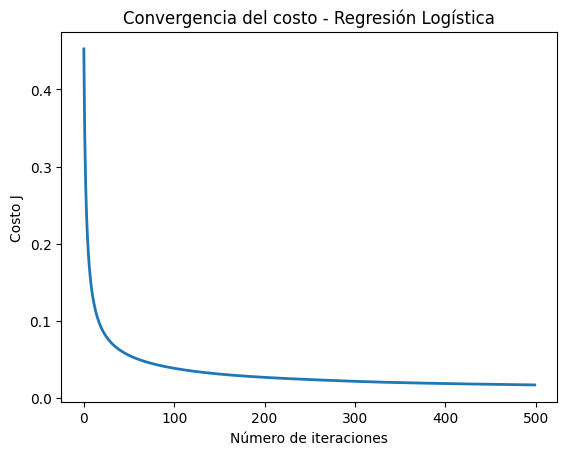

In [191]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)

plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo - Regresión Logística')

plt.show() # El costo disminuya y termine estabilizándose.

## **6. Predicción y validación**

Una vez entrenado el modelo, se utilizan los parámetros theta obtenidos para realizar predicciones sobre el 20% de datos reservado para prueba. Una probabilidad mayor o igual a 0.5 se clasifica como Malware (1), y una probabilidad menor a 0.5 como Benign (0).

1. Función de predicción

In [192]:
def predict(theta):
    probabilidades = sigmoid(X_test_bias.dot(theta))
    predicciones = (probabilidades >= 0.5).astype(int)

    return predicciones

2. Evaluar con el conjunto de prueba

Aquí lo importante es que estamos usando:


*   X_test
*   y_test


los 11.613 ejemplos que nunca participaron en el entrenamiento.

In [193]:
pred_test = predict(theta)

precision = np.mean(pred_test == y_test) * 100

print("Precisión del conjunto de prueba: {:.2f}%".format(precision))

Precisión del conjunto de prueba: 99.64%


3. Matriz de confusión

Interpretación:

- VN: era benigno y predijo benigno.
- VP: era malware y predijo malware.
- FP: era benigno pero dijo malware.
- FN: era malware pero dijo benigno.

In [194]:
VP = np.sum((y_test == 1) & (pred_test == 1))
VN = np.sum((y_test == 0) & (pred_test == 0))
FP = np.sum((y_test == 0) & (pred_test == 1))
FN = np.sum((y_test == 1) & (pred_test == 0))

print("Matriz de confusión")
print("-----------------------------")
print("Verdaderos Negativos:", VN)
print("Falsos Positivos:    ", FP)
print("Falsos Negativos:    ", FN)
print("Verdaderos Positivos:", VP)

Matriz de confusión
-----------------------------
Verdaderos Negativos: 5913
Falsos Positivos:     29
Falsos Negativos:     13
Verdaderos Positivos: 5658


4. Algunas predicciones

In [195]:
probabilidades = sigmoid(X_test_bias.dot(theta))

print("Ejemplos de predicción:\n")

for i in range(10):
    real = "Malware" if y_test[i] == 1 else "Benign"
    predicho = "Malware" if pred_test[i] == 1 else "Benign"

    print(
        f"Ejemplo {i+1}: "
        f"Real = {real} | "
        f"Predicción = {predicho} | "
        f"Probabilidad = {probabilidades[i]:.4f}"
    )

Ejemplos de predicción:

Ejemplo 1: Real = Malware | Predicción = Malware | Probabilidad = 0.9977
Ejemplo 2: Real = Malware | Predicción = Malware | Probabilidad = 0.9905
Ejemplo 3: Real = Benign | Predicción = Benign | Probabilidad = 0.0003
Ejemplo 4: Real = Benign | Predicción = Benign | Probabilidad = 0.0248
Ejemplo 5: Real = Benign | Predicción = Benign | Probabilidad = 0.0008
Ejemplo 6: Real = Malware | Predicción = Malware | Probabilidad = 0.9960
Ejemplo 7: Real = Benign | Predicción = Benign | Probabilidad = 0.0001
Ejemplo 8: Real = Benign | Predicción = Benign | Probabilidad = 0.0029
Ejemplo 9: Real = Benign | Predicción = Benign | Probabilidad = 0.0016
Ejemplo 10: Real = Malware | Predicción = Malware | Probabilidad = 0.5876
